<h1 style="color: red; font-size: 48px; text-align: center;">Multi-Signal Demand Forecasting</h1>

<center>
    <img src="https://media.giphy.com/media/26tn33aiTi1jkl6H6/giphy.gif" alt="retail demand forecasting" height="200" width="500">
</center>

# 👋 Introduction

<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    The objective of this project is to build a predictive model that forecasts <b>daily retail demand (Sales)</b> for the
    <b>Rossmann Store Sales</b> dataset. Accurate demand forecasts let retailers plan inventory, staffing, and promotions,
    avoid stock-outs and overstock, and turn predictions into concrete business actions such as automated purchase orders.
    We enrich the model with <b>multi-signal context</b> (weather, search interest, and financial-news sentiment) and learn
    the complex relationship between store, calendar, and promotional factors and the number of units sold.
</div>

# 📚 Problem Statement

<div class="alert alert-block alert-info" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    Retail demand is driven by a combination of factors including store type, assortment, competition, promotions,
    holidays, and seasonality. Manually anticipating demand for every store on every day is slow and error-prone.
    By leveraging a data-driven approach we automate this forecasting process, improving the consistency and accuracy
    of demand estimates and enabling data-informed decisions for replenishment and promotion planning.
</div>

# 🔭 Feature Description

<div style="font-family:verdana; font-size: 20px; line-height: 1.7em;">
<ol>
<li><p><strong><code>Store</code></strong>: A unique identifier for each Rossmann store. Different stores have distinct baseline demand levels and customer profiles.</p></li>

<li><p><strong><code>DayOfWeek</code></strong>: The day of the week (1 = Monday … 7 = Sunday). Demand follows a strong weekly cycle, with weekends behaving differently from weekdays.</p></li>

<li><p><strong><code>Date</code></strong>: The calendar date of the observation. Used to derive year, month, day, and week-of-year features that capture seasonality and trend.</p></li>

<li><p><strong><code>Promo</code></strong>: A binary indicator (1 = yes, 0 = no) of whether a store was running a promotion that day. Promotions typically lift sales substantially.</p></li>

<li><p><strong><code>StateHoliday</code></strong>: Indicates a state holiday (a = public, b = Easter, c = Christmas, 0 = none). Most stores close on holidays, which strongly affects demand.</p></li>

<li><p><strong><code>SchoolHoliday</code></strong>: A binary indicator (1 = yes, 0 = no) of whether the store was affected by the closure of public schools, which shifts foot traffic.</p></li>

<li><p><strong><code>StoreType</code></strong>: The store model/category (a, b, c, d). Different store types have different sizes, ranges, and demand patterns.</p></li>

<li><p><strong><code>Assortment</code></strong>: The assortment level (a = basic, b = extra, c = extended). A wider assortment can attract more customers and increase sales.</p></li>

<li><p><strong><code>CompetitionDistance</code></strong>: The distance in metres to the nearest competitor store. Closer competition can dampen demand.</p></li>

<li><p><strong><code>Promo2</code></strong>: A binary feature (1 = participating, 0 = not) indicating whether the store takes part in a continuing, consecutive promotion.</p></li>

<li><p><strong><code>Customers</code></strong>: The number of customers on a given day (available in training only). Strongly correlated with sales and useful for analysis.</p></li>

<li><p><strong><code>Sales</code></strong>: The target variable — the turnover (units/currency of sales) for a given store on a given day. This is a numeric outcome modeled using regression algorithms.</p></li>
</ol>

<p>
These features collectively capture the store characteristics, calendar and promotional context, and competitive
environment that drive retail demand. Understanding their interactions is key to building an effective forecasting model.
</p>
</div>

# 🎯 Project Goals

<div class="alert alert-block alert-warning" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    <ul>
        <li>Perform exploratory data analysis (EDA) to identify demand trends, seasonality, and correlations.</li>
        <li>Engineer relevant calendar, promotional, and store features that improve predictive performance.</li>
        <li>Develop baseline regression models and compare performance using RMSE, MAE, and R² metrics.</li>
        <li>Use model interpretation to understand the key drivers of retail demand.</li>
        <li>Propose actionable insights for inventory replenishment and promotion planning.</li>
    </ul>
</div>

# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from rich.console import Console
from rich.table import Table

warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set(font_scale=1.1)

# Load Data

In [2]:
train = pd.read_csv("/kaggle/input/rossmann-store-sales/train.csv", low_memory=False)
test = pd.read_csv("/kaggle/input/rossmann-store-sales/test.csv")
store = pd.read_csv("/kaggle/input/rossmann-store-sales/store.csv")

In [3]:
# Merge store metadata into both train and test on Store
train = train.merge(store, on="Store", how="left")
test = test.merge(store, on="Store", how="left")

In [4]:
# Parse dates and derive simple calendar parts (no heavy feature engineering)
for df in (train, test):
    df["Date"] = pd.to_datetime(df["Date"])
    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month
    df["Day"] = df["Date"].dt.day
    df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)

# Keep only open days with positive sales for modelling demand
train = train[(train["Open"] == 1) & (train["Sales"] > 0)].reset_index(drop=True)

In [5]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear
0,1,3,2014-01-01,4783,429,1,0,0,0,d,...,6,2012,0,36,2010,NaN,2014,1,1,1
1,1,4,2014-01-02,4449,380,1,0,0,0,d,...,6,2012,0,36,2010,NaN,2014,1,2,1
2,1,5,2014-01-03,3937,441,1,0,0,0,d,...,6,2012,0,36,2010,NaN,2014,1,3,1
3,1,6,2014-01-04,5250,498,1,1,0,0,d,...,6,2012,0,36,2010,NaN,2014,1,4,1
4,1,1,2014-01-06,4905,441,1,0,0,0,d,...,6,2012,0,36,2010,NaN,2014,1,6,2


In [6]:
def custom_describe(df, categorical=False):

    if not categorical:
        df = df.select_dtypes(include=np.number)

    des = df.describe().T.round(2)
    des['count'] = des['count'].astype('int')

    if not categorical:
        des['skewness'] = df.skew().round(2)
        des['kurtosis'] = df.kurtosis().round(2)

    return des

In [7]:
def df_summary(df, label="Train"):
    console = Console()
    console.rule(f"[bold blue]{label} DataFrame Description[/bold blue]")

    console.print(f"[bold]Shape:[/bold] {df.shape}\n")

    # Numeric summary
    numeric_cols = df.select_dtypes(include=np.number).columns
    if len(numeric_cols) > 0:
        console.print("[bold blue]Numerical Columns:[/bold blue]")
        num_stats = custom_describe(df[numeric_cols], categorical=False)
        table = Table(show_header=True, header_style="bold magenta")
        table.add_column("Column")
        for col in num_stats.columns:
            table.add_column(col)
        for idx, row in num_stats.iterrows():
            table.add_row(idx, *[f"{val:.2f}" if isinstance(val, (float, np.float64)) else str(val) for val in row])
        console.print(table)
        console.print("\n")

    # Categorical summary
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    if len(cat_cols) > 0:
        console.print("[bold blue]Categorical Columns:[/bold blue]")
        cat_stats = df[cat_cols].describe().T
        table = Table(show_header=True, header_style="bold magenta")
        table.add_column("Column")
        for col in cat_stats.columns:
            table.add_column(col)
        for idx, row in cat_stats.iterrows():
            table.add_row(idx, *[str(val) for val in row])
        console.print(table)
        console.print("\n")

df_summary(train)
df_summary(test, "Test")

─────────────────────────────────────────── Train DataFrame Description ───────────────────────────────────────────

Shape: (1134, 22)

Numerical Columns:

┏━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┓
┃ Column   ┃ count   ┃ mean     ┃ std     ┃ min     ┃ 25%     ┃ 50%     ┃ 75%      ┃ max     ┃ skewness ┃ kurtos… ┃
┡━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━┩
│ Store    │ 1134.00 │ 3.50     │ 1.71    │ 1.00    │ 2.00    │ 3.50    │ 5.00     │ 6.00    │ 0.00     │ -1.27   │
│ DayOfWe… │ 1134.00 │ 3.51     │ 1.70    │ 1.00    │ 2.00    │ 4.00    │ 5.00     │ 6.00    │ -0.01    │ -1.26   │
│ Sales    │ 1134.00 │ 5686.72  │ 1397.10 │ 3157.00 │ 4663.50 │ 5463.50 │ 6473.00  │ 10701.… │ 0.76     │ 0.30    │
│ Custome… │ 1134.00 │ 575.51   │ 159.40  │ 274.00  │ 458.00  │ 548.00  │ 666.00   │ 1158.00 │ 0.86     │ 0.57    │
│ Open     │ 1134.00 │ 1.00     │ 0.00    │ 1.00    │ 1.00    │ 1.00    │ 1.00     │ 1.00    │ 0.00     │ 0.00    │
│ Promo    │ 1134.00 │ 0.40     │ 0.49    │ 0.00    │ 0.00    │ 0.00    │ 1.00     │ 1.00    │ 0.41     │ -1.83   │
│ StateHo… │ 1134.00 │ 0.00     │ 0.00    │ 0.00    │ 0.00    │ 0.00    │ 0.00     │ 0.00    │ 0.00     │ 0.00    │
│ SchoolH… │ 1134.00 │ 0.11     │ 0.31    │ 0.00    │ 0.00    │ 0.00    │ 0.00     │ 1.00    │ 2.52     │ 4.37    │
│ Competi… │ 1134.00 │ 11244.50 │ 5426.71 │ 3916.00 │ 6356.00 │ 11210.… │ 14966.00 │ 19809.… │ 0.18     │ -1.25   │
│ Competi… │ 1134.00 │ 5.50     │ 2.69    │ 2.00    │ 2.00    │ 6.00    │ 8.00     │ 9.00    │ -0.23    │ -1.45   │
│ Competi… │ 1134.00 │ 2006.67  │ 5.71    │ 2000.00 │ 2001.00 │ 2007.00 │ 2012.00  │ 2013.00 │ -0.02    │ -1.95   │
│ Promo2   │ 1134.00 │ 0.50     │ 0.50    │ 0.00    │ 0.00    │ 0.50    │ 1.00     │ 1.00    │ 0.00     │ -2.00   │
│ Promo2S… │ 1134.00 │ 31.00    │ 12.07   │ 9.00    │ 29.00   │ 31.00   │ 36.00    │ 50.00   │ -0.35    │ -0.13   │
│ Promo2S… │ 1134.00 │ 2010.33  │ 0.47    │ 2010.00 │ 2010.00 │ 2010.00 │ 2011.00  │ 2011.00 │ 0.71     │ -1.50   │
│ Year     │ 1134.00 │ 2014.00  │ 0.00    │ 2014.00 │ 2014.00 │ 2014.00 │ 2014.00  │ 2014.00 │ 0.00     │ 0.00    │
│ Month    │ 1134.00 │ 4.16     │ 2.11    │ 1.00    │ 2.00    │ 4.00    │ 6.00     │ 8.00    │ 0.02     │ -1.18   │
│ Day      │ 1134.00 │ 15.32    │ 8.88    │ 1.00    │ 7.00    │ 15.00   │ 23.00    │ 31.00   │ 0.07     │ -1.22   │
│ WeekOfY… │ 1134.00 │ 16.58    │ 9.10    │ 1.00    │ 9.00    │ 17.00   │ 24.00    │ 32.00   │ -0.00    │ -1.20   │
└──────────┴─────────┴──────────┴─────────┴─────────┴─────────┴─────────┴──────────┴─────────┴──────────┴─────────┘

Categorical Columns:

...

Shape: (264, 21)

Numerical Columns:

┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┓
┃ Column   ┃ count  ┃ mean     ┃ std     ┃ min     ┃ 25%     ┃ 50%      ┃ 75%      ┃ max     ┃ skewness ┃ kurtos… ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━┩
│ Id       │ 264.00 │ 132.50   │ 76.35   │ 1.00    │ 66.75   │ 132.50   │ 198.25   │ 264.00  │ 0.00     │ -1.20   │
│ Store    │ 264.00 │ 3.50     │ 1.71    │ 1.00    │ 2.00    │ 3.50     │ 5.00     │ 6.00    │ 0.00     │ -1.27   │
│ DayOfWe… │ 264.00 │ 4.02     │ 1.96    │ 1.00    │ 2.00    │ 4.00     │ 6.00     │ 7.00    │ -0.03    │ -1.19   │
│ Open     │ 264.00 │ 0.86     │ 0.34    │ 0.00    │ 1.00    │ 1.00     │ 1.00     │ 1.00    │ -2.13    │ 2.56    │
│ Promo    │ 264.00 │ 0.37     │ 0.48    │ 0.00    │ 0.00    │ 0.00     │ 1.00     │ 1.00    │ 0.55     │ -1.71   │
│ StateHo… │ 264.00 │ 0.00     │ 0.00    │ 0.00    │ 0.00    │ 0.00     │ 0.00     │ 0.00    │ 0.00     │ 0.00    │
│ SchoolH… │ 264.00 │ 0.12     │ 0.32    │ 0.00    │ 0.00    │ 0.00     │ 0.00     │ 1.00    │ 2.39     │ 3.74    │
│ Competi… │ 264.00 │ 11244.50 │ 5434.62 │ 3916.00 │ 6356.00 │ 11210.00 │ 14966.00 │ 19809.… │ 0.18     │ -1.25   │
│ Competi… │ 264.00 │ 5.50     │ 2.70    │ 2.00    │ 2.00    │ 6.00     │ 8.00     │ 9.00    │ -0.23    │ -1.45   │
│ Competi… │ 264.00 │ 2006.67  │ 5.72    │ 2000.00 │ 2001.00 │ 2007.00  │ 2012.00  │ 2013.00 │ -0.02    │ -1.96   │
│ Promo2   │ 264.00 │ 0.50     │ 0.50    │ 0.00    │ 0.00    │ 0.50     │ 1.00     │ 1.00    │ 0.00     │ -2.02   │
│ Promo2S… │ 264.00 │ 31.00    │ 12.09   │ 9.00    │ 29.00   │ 31.00    │ 36.00    │ 50.00   │ -0.35    │ -0.11   │
│ Promo2S… │ 264.00 │ 2010.33  │ 0.47    │ 2010.00 │ 2010.00 │ 2010.00  │ 2011.00  │ 2011.00 │ 0.71     │ -1.51   │
│ Year     │ 264.00 │ 2014.00  │ 0.00    │ 2014.00 │ 2014.00 │ 2014.00  │ 2014.00  │ 2014.00 │ 0.00     │ 0.00    │
│ Month    │ 264.00 │ 7.07     │ 0.54    │ 6.00    │ 7.00    │ 7.00     │ 7.00     │ 8.00    │ 0.05     │ 0.40    │
│ Day      │ 264.00 │ 15.27    │ 9.89    │ 1.00    │ 6.00    │ 14.50    │ 25.25    │ 31.00   │ 0.11     │ -1.47   │
│ WeekOfY… │ 264.00 │ 29.07    │ 1.85    │ 26.00   │ 27.75   │ 29.00    │ 31.00    │ 32.00   │ -0.01    │ -1.13   │
└──────────┴────────┴──────────┴─────────┴─────────┴─────────┴──────────┴──────────┴─────────┴──────────┴─────────┘

Categorical Columns:

┏━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━┓
┃ Column        ┃ count ┃ unique ┃ top             ┃ freq ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━┩
│ StoreType     │ 264   │ 4      │ d               │ 88   │
│ Assortment    │ 264   │ 3      │ a               │ 132  │
│ PromoInterval │ 176   │ 2      │ Feb,May,Aug,Nov │ 132  │
└───────────────┴───────┴────────┴─────────────────┴──────┘

# 🔍 Exploratory Data Analysis (EDA)

<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    The goal of Exploratory Data Analysis (EDA) is to better understand the underlying structure and patterns of the dataset.
    By visualizing and summarizing the data, we can identify correlations between store, promotional, and calendar features,
    and determine which conditions are most associated with higher retail demand (Sales).
</div>

## 📊 Key Objectives of EDA

<div class="alert alert-block alert-info" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    <ul>
        <li>Examine the distribution of each feature and detect potential outliers or anomalies.</li>
        <li>Understand the relationship between <code>Sales</code> and other predictors.</li>
        <li>Visualize trends across time-related features such as <code>DayOfWeek</code>, <code>Month</code>, and <code>StateHoliday</code>.</li>
        <li>Assess how promotional and store factors like <code>Promo</code>, <code>StoreType</code>, and <code>Assortment</code> influence demand.</li>
        <li>Identify feature correlations and multicollinearity using a correlation matrix or heatmap.</li>
    </ul>
</div>

## 📈 Exploratory Steps

<div style="font-family: verdana; font-size: 20px; line-height: 1.7em;">
<ol>
<li><p><strong>Check for Missing Values:</strong> Use summary statistics and <code>isnull()</code> checks to ensure data completeness.
Missing data in features like <code>CompetitionDistance</code> or the <code>Promo2</code> fields can bias the model if not handled properly.</p></li>

<li><p><strong>Univariate Analysis:</strong>
    Explore individual feature distributions using histograms, boxplots, or bar charts.
    For example:
    <ul>
        <li>Distribution of <code>Sales</code> and <code>CompetitionDistance</code></li>
        <li>Frequency counts of categorical variables such as <code>StoreType</code> and <code>Assortment</code></li>
    </ul>
</p></li>

<li><p><strong>Bivariate Analysis:</strong>
    Study the relationship between the target variable (<code>Sales</code>) and each feature:
    <ul>
        <li>Average sales per <code>StoreType</code></li>
        <li>Sales by <code>Promo</code> and <code>SchoolHoliday</code> conditions</li>
        <li>Sales across <code>DayOfWeek</code> and <code>Month</code></li>
        <li>Boxplots of <code>Assortment</code> vs <code>Sales</code></li>
    </ul>
</p></li>

<li><p><strong>Multivariate Analysis:</strong>
    Examine combined effects of multiple features (e.g., <i>promo + weekend + extended assortment</i>) on demand.
    Use pairplots, grouped bar charts, or heatmaps to identify potential interaction effects.</p></li>

<li><p><strong>Correlation Analysis:</strong>
    Compute the correlation matrix for numerical variables and visualize it with a heatmap.
    This helps in identifying redundant or strongly correlated predictors.</p></li>

<li><p><strong>Outlier Detection:</strong>
    Detect extreme values in continuous variables like <code>Sales</code> and <code>CompetitionDistance</code>.
    Outliers can indicate special events or rare but important high-demand days.</p></li>

<li><p><strong>Temporal Trends:</strong>
    Visualize sales by day-of-week, month, and season to identify temporal demand patterns and seasonality.</p></li>
</ol>

<p>
The insights gained from EDA will guide feature selection, data transformations, and model design decisions.
Understanding which combinations of store, promotional, and calendar conditions increase demand
will also help in formulating actionable recommendations for replenishment and promotion planning.
</p>
</div>

In [8]:
target = "Sales"
drop_cols = ["Sales", "Customers", "Date", "Open"]
features = [c for c in train.columns if c not in drop_cols]
numerical_features = train[features].select_dtypes(include=np.number).columns.to_list()
categorical_features = train[features].select_dtypes(exclude=np.number).columns.to_list()

## Null Value Check

In [9]:
pd.DataFrame({
    'Columns': train.columns.to_list(),
    '# Null': train.isna().sum().values
})

,Columns,# Null
0,Store,0
1,DayOfWeek,0
2,Date,0
3,Sales,0
4,Customers,0
5,Open,0
6,Promo,0
7,StateHoliday,0
8,SchoolHoliday,0
9,StoreType,0


## Duplicate Check

In [10]:
num_duplicates = train.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

if num_duplicates > 0:
    train = train.drop_duplicates()

Number of duplicate rows: 0


## Univariate Analysis

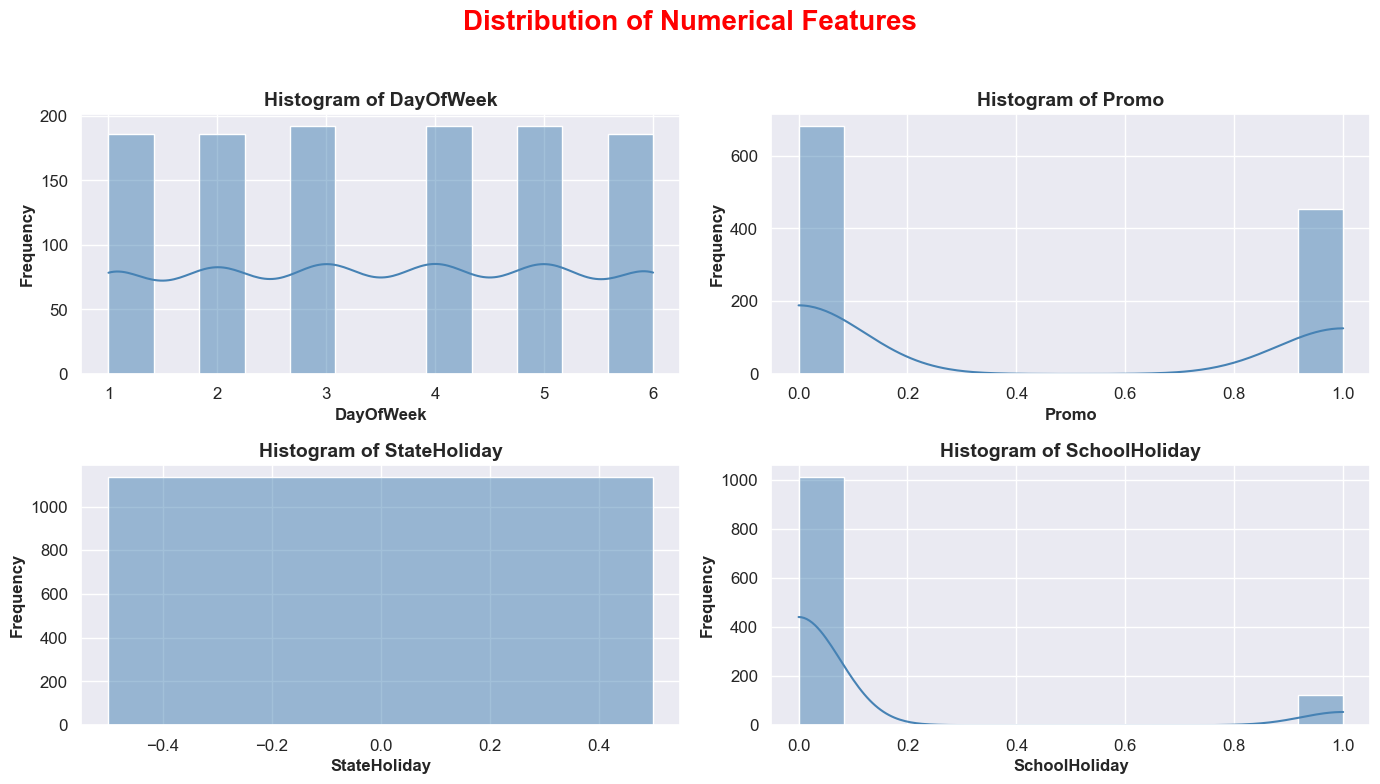

In [11]:
plot_num = [f for f in numerical_features if f not in ("Store", "Year")][:4]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, feature in enumerate(plot_num):
    if pd.api.types.is_integer_dtype(train[feature]):
        sns.histplot(data=train, x=feature, ax=axes[i], kde=True, color='steelblue')
        axes[i].set_title(f"Histogram of {feature}", fontweight="bold", fontsize=14)
    else:
        sns.kdeplot(data=train, x=feature, ax=axes[i], fill=True, color='seagreen')
        axes[i].set_title(f"KDE Plot of {feature}", fontweight="bold", fontsize=14)

    axes[i].set_xlabel(feature, fontsize=12, fontweight="bold")
    axes[i].set_ylabel("Frequency", fontsize=12, fontweight="bold")

plt.suptitle("Distribution of Numerical Features", fontsize=20, fontweight="bold", color="red")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

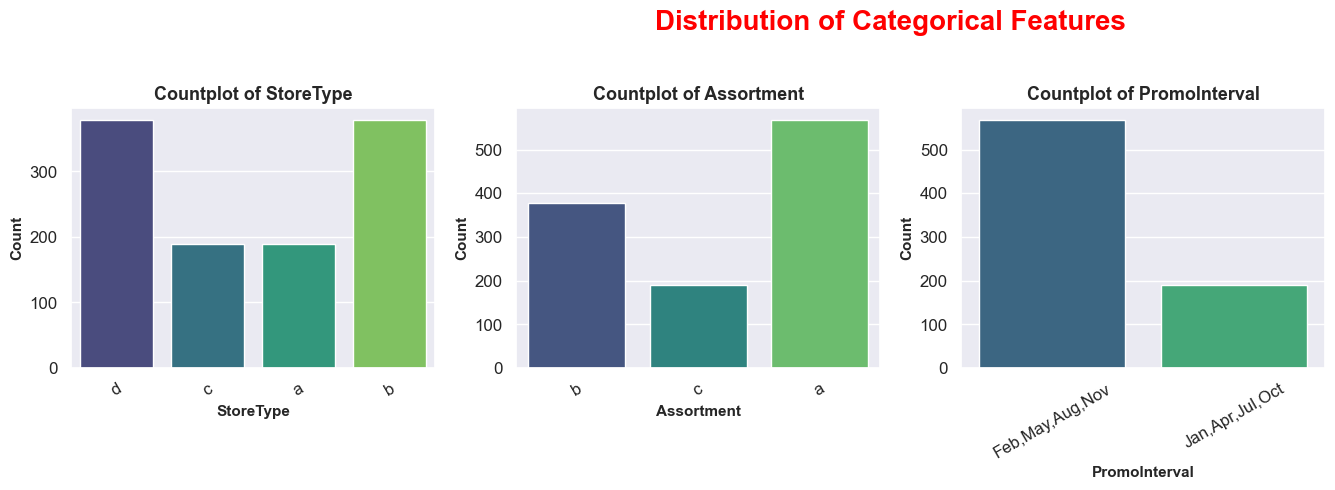

In [12]:
plot_cat = categorical_features[:8]

n = len(plot_cat)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = np.array(axes).flatten()

for i, feature in enumerate(plot_cat):
    sns.countplot(data=train, x=feature, ax=axes[i], palette='viridis')
    axes[i].set_title(f"Countplot of {feature}", fontweight="bold", fontsize=13)
    axes[i].set_xlabel(feature, fontsize=11, fontweight="bold")
    axes[i].set_ylabel("Count", fontsize=11, fontweight="bold")
    axes[i].tick_params(axis='x', rotation=30)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution of Categorical Features", fontsize=20, fontweight="bold", color="red")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Target Analysis

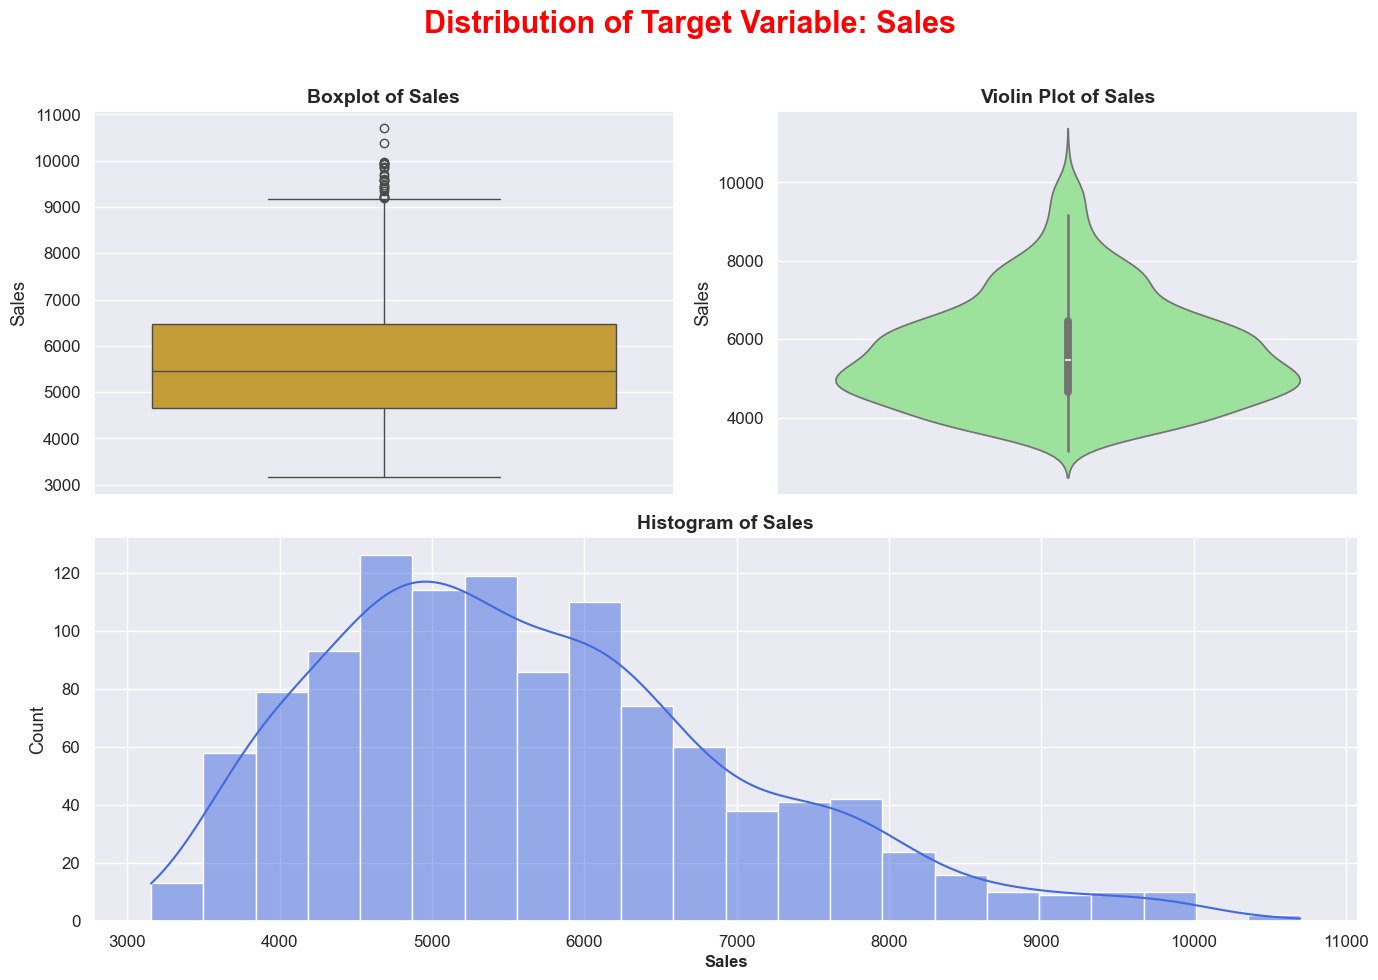

In [13]:
fig, axes = plt.subplot_mosaic([['A', 'B'], ['C', 'C']], figsize=(14, 10))
sns.boxplot(y=target, data=train, ax=axes['A'], color='goldenrod')
axes['A'].set_title(f"Boxplot of {target}", fontweight="bold", fontsize=14)

sns.violinplot(y=target, data=train, ax=axes['B'], color='lightgreen')
axes['B'].set_title(f"Violin Plot of {target}", fontweight="bold", fontsize=14)

sns.histplot(train[target], kde=True, ax=axes['C'], color='royalblue')
axes['C'].set_title(f"Histogram of {target}", fontweight="bold", fontsize=14)
axes['C'].set_xlabel(target, fontsize=12, fontweight="bold")

plt.suptitle(f"Distribution of Target Variable: {target}", fontsize=22, fontweight="bold", color='red')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Bivariate Analysis

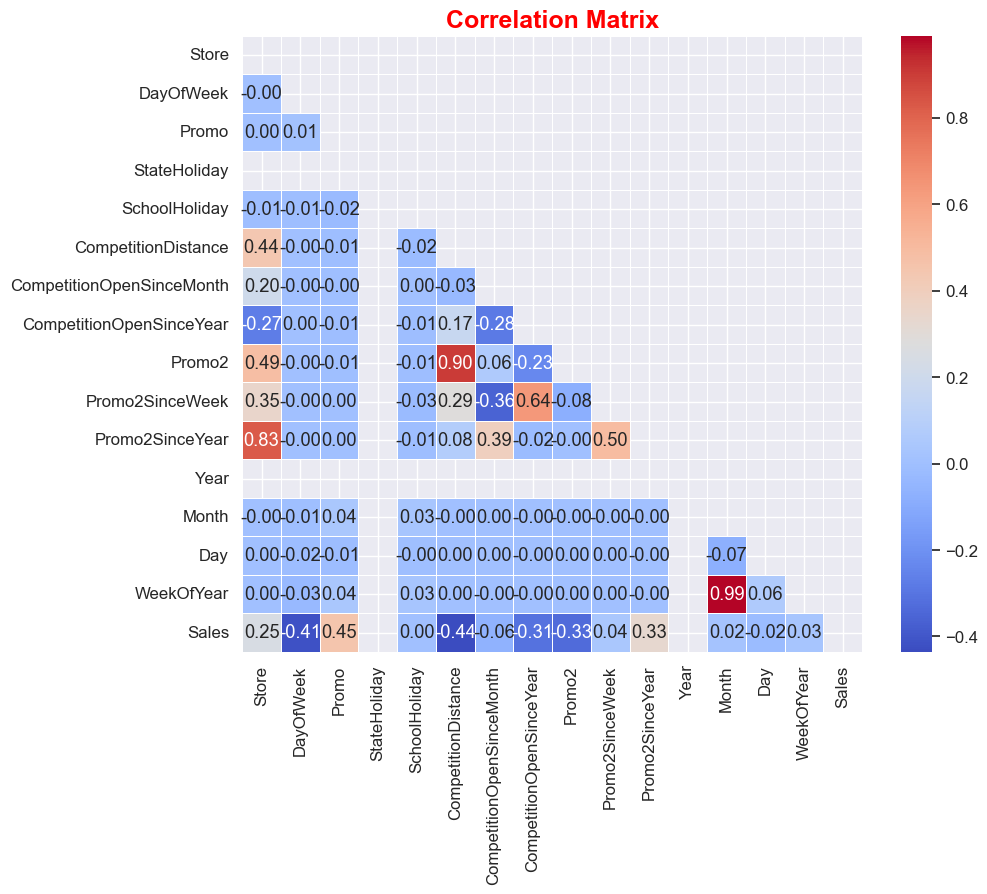

In [14]:
corr = train[numerical_features + [target]].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=18, fontweight="bold", color="red")
plt.show()

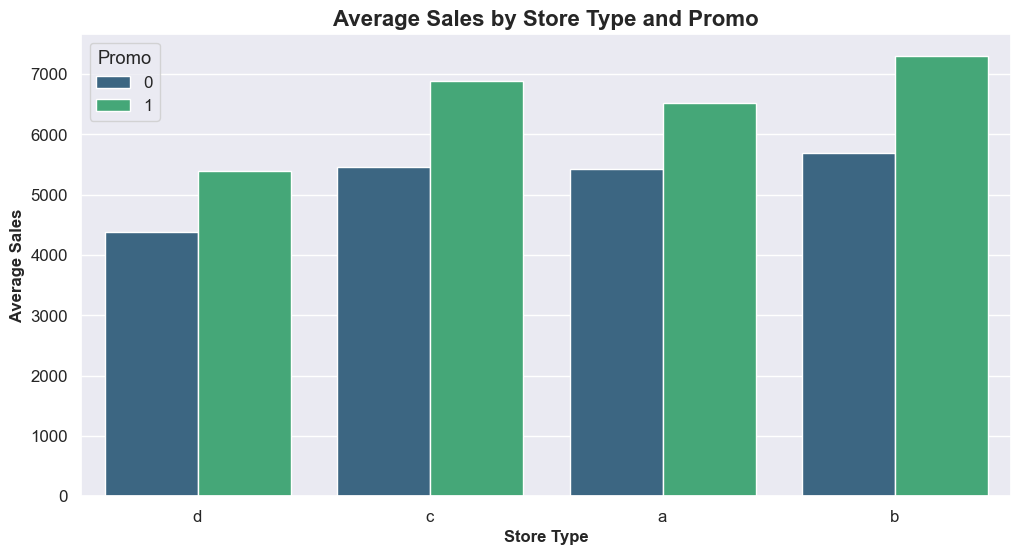

In [15]:
plt.figure(figsize=(12, 6))
sns.barplot(x='StoreType', y=target, hue='Promo', data=train, errorbar=None, palette='viridis')
plt.title("Average Sales by Store Type and Promo", fontsize=16, fontweight='bold')
plt.xlabel("Store Type", fontsize=12, fontweight='bold')
plt.ylabel("Average Sales", fontsize=12, fontweight='bold')
plt.legend(title="Promo")
plt.show()

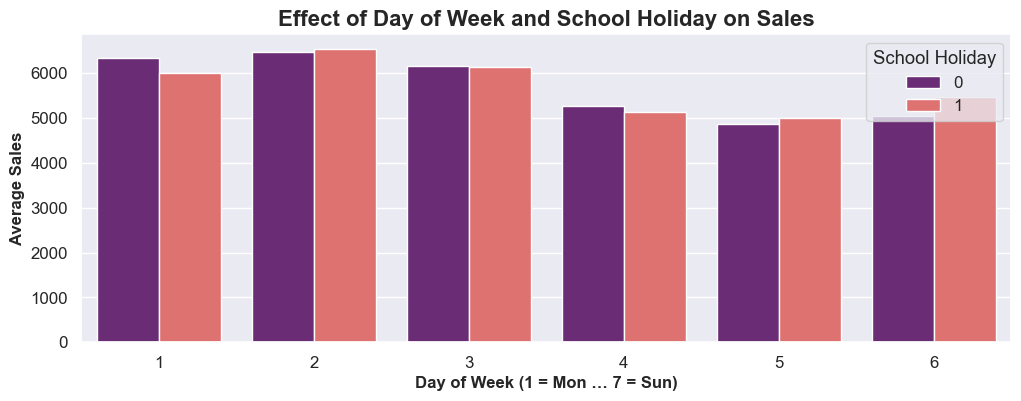

In [16]:
plt.figure(figsize=(12, 4))
sns.barplot(x='DayOfWeek', y=target, hue='SchoolHoliday', data=train, errorbar=None, palette='magma')
plt.title("Effect of Day of Week and School Holiday on Sales", fontsize=16, fontweight='bold')
plt.xlabel("Day of Week (1 = Mon … 7 = Sun)", fontsize=12, fontweight='bold')
plt.ylabel("Average Sales", fontsize=12, fontweight='bold')
plt.legend(title="School Holiday")
plt.show()

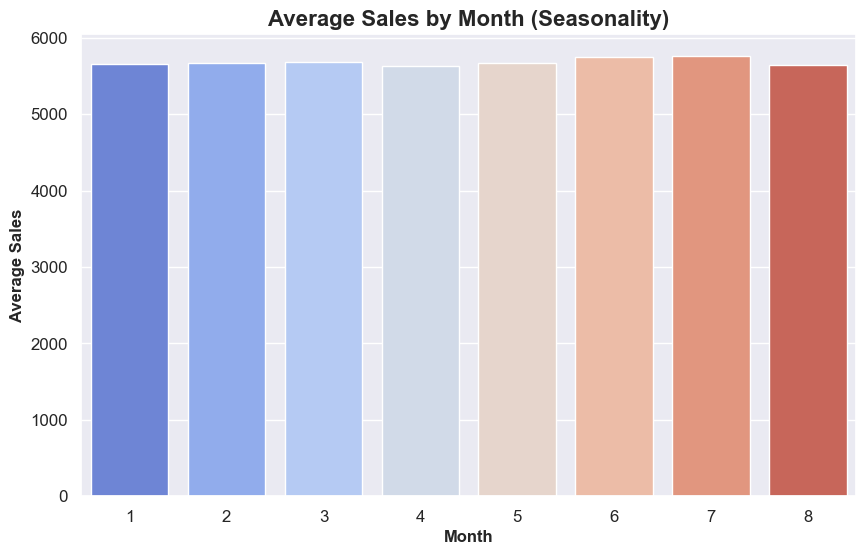

In [17]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Month', y=target, data=train, errorbar=None, palette='coolwarm')
plt.title("Average Sales by Month (Seasonality)", fontsize=16, fontweight='bold')
plt.xlabel("Month", fontsize=12, fontweight='bold')
plt.ylabel("Average Sales", fontsize=12, fontweight='bold')
plt.show()

# 🛠️ Feature Engineering & Preprocessing

<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    Before training machine learning models, it is crucial to prepare the dataset.
    Feature engineering and preprocessing help improve model performance by transforming raw data into meaningful representations,
    handling categorical variables, scaling numerical features, and dealing with missing or inconsistent data.
</div>

## 🔧 Key Preprocessing Steps

<div class="alert alert-block alert-info" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    <ul>
        <li><strong>Encoding Categorical Variables:</strong> Convert categorical features into numerical format for ML models.
        Options include:
            <ul>
                <li><code>One-Hot Encoding</code> for features with no ordinal relationship (e.g., <code>StoreType</code>, <code>StateHoliday</code>).</li>
                <li><code>Ordinal Encoding</code> if categories have an inherent order such as <code>Assortment</code> (optional).</li>
            </ul>
        </li>
        <li><strong>Scaling Numerical Features:</strong> Standardize or normalize features like <code>CompetitionDistance</code> and <code>WeekOfYear</code> to help gradient-based models converge faster.</li>
        <li><strong>Feature Transformation:</strong> Apply transformations to reduce skewness or highlight patterns:
            <ul>
                <li>Log transformation for skewed <code>Sales</code> and <code>CompetitionDistance</code></li>
                <li>Interaction terms (e.g., <code>Promo × DayOfWeek</code>) to capture non-linear demand effects</li>
            </ul>
        </li>
        <li><strong>Temporal Features:</strong> Encode cyclical calendar fields such as <code>Month</code> and <code>DayOfWeek</code> using sine and cosine transformations to preserve circularity.</li>
        <li><strong>Target Transformation:</strong> Sales are right-skewed, so we model <code>log1p(Sales)</code> to improve stability and reduce the influence of extreme high-demand days.</li>
    </ul>
</div>

# 🏗️ Model Building

<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    In this section, we will train regression models to predict <strong>Sales</strong> using the preprocessed features.
    Our goal is to accurately forecast daily retail demand based on store, promotional, and calendar features.
</div>

## 🔭 Choice of Models

<div class="alert alert-block alert-info" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    Common regression models suitable for this problem include:
    <ul>
        <li><strong>Random Forest Regressor:</strong> Handles nonlinear relationships, robust to outliers, no feature scaling needed.</li>
        <li><strong>Gradient Boosting Regressor (XGBoost / LightGBM / CatBoost):</strong> High performance for tabular demand data with complex interactions.</li>
        <li><strong>Linear Regression / Ridge / Lasso:</strong> Good baseline models; require scaling of numerical features.</li>
    </ul>
    We blend several gradient-boosting models with a Ridge meta-learner. (The full project also trains a
    <strong>Temporal Fusion Transformer</strong> for probabilistic P10/P50/P90 forecasts — see the repository.)
</div>

In [18]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold

from sklearn.ensemble import RandomForestRegressor

In [19]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score

import lightgbm as lgb

def model_trainer(model, X, y, test=None, nsplits=5, random_state=42, log_target=False, verbose=0, model_name=None):

    kfold = KFold(n_splits=nsplits, shuffle=True, random_state=random_state)

    if isinstance(X, pd.DataFrame):
        X = X.to_numpy()
    y_array = y.to_numpy() if isinstance(y, pd.Series) else y.copy()

    if log_target:
        y_array = np.log1p(y_array)

    oof_train_preds = np.zeros(len(y_array))
    if test is not None:
        if isinstance(test, pd.DataFrame):
            test = test.to_numpy()
        oof_test_preds = np.zeros(len(test))

    oof_rmse = []
    oof_r2 = []

    for fold, (train_idx, val_idx) in enumerate(kfold.split(X), 1):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y_array[train_idx], y_array[val_idx]

        if model_name == 'xgb':
            model.fit(X_train, y_train,
                      eval_set=[(X_val, y_val)],
                      verbose=verbose)
            if hasattr(model, 'best_iteration') and model.best_iteration is not None:
                y_pred = model.predict(X_val, iteration_range=(0, model.best_iteration + 1))
            else:
                y_pred = model.predict(X_val)

        elif model_name == 'lgb':
            model.fit(X_train, y_train,
                      eval_set=[(X_val, y_val)],
                      callbacks=[lgb.early_stopping(200, verbose=verbose)])
            y_pred = model.predict(X_val)

        elif model_name == 'cat':
            model.fit(X_train, y_train,
                      eval_set=[(X_val, y_val)],
                      early_stopping_rounds=200,
                      verbose=verbose)
            y_pred = model.predict(X_val)

        elif model_name == 'hgb':
            model.fit(X_train, y_train, )
            y_pred = model.predict(X_val)

        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

        if log_target:
            y_val_exp = np.expm1(y_val)
            y_pred_exp = np.expm1(y_pred)
        else:
            y_val_exp = y_val
            y_pred_exp = y_pred

        rmse = np.sqrt(mean_squared_error(y_val_exp, y_pred_exp))
        r2 = r2_score(y_val_exp, y_pred_exp)
        oof_rmse.append(rmse)
        oof_r2.append(r2)

        oof_train_preds[val_idx] = y_pred_exp

        if test is not None:
            test_pred = None
            if model_name == 'xgb':
                if hasattr(model, 'best_iteration') and model.best_iteration is not None:
                    test_pred = model.predict(test, iteration_range=(0, model.best_iteration + 1))
                else:
                    test_pred = model.predict(test)
            else:
                test_pred = model.predict(test)

            if log_target:
                test_pred = np.expm1(test_pred)

            oof_test_preds += test_pred / nsplits

        print(f"Fold {fold} → RMSE: {rmse:.4f}, R2: {r2:.4f}")

    print(f"\nAverage Fold RMSE Score: {np.mean(oof_rmse):.4f} ± {np.std(oof_rmse):.4f}")
    print(f"Average Fold R2 Score: {np.mean(oof_r2):.4f} ± {np.std(oof_r2):.4f}")

    if test is not None:
        return oof_train_preds, oof_test_preds

    return oof_train_preds

In [20]:
# Align test feature columns to the training feature set
test_features = test[[c for c in features if c in test.columns]].copy()

numeric_transformer = MinMaxScaler()
categorical_transformer = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [21]:
X = train[features].copy()
y = train[target].copy()

# Fill the few missing values so the encoders/scalers are happy
for col in numerical_features:
    fill = pd.concat([X[col], test_features[col]]).median()
    X[col] = X[col].fillna(fill)
    test_features[col] = test_features[col].fillna(fill)
for col in categorical_features:
    X[col] = X[col].astype(str).fillna("NA")
    test_features[col] = test_features[col].astype(str).fillna("NA")

In [22]:
comb = pd.concat([X, test_features], axis=0)

preprocessor.fit(comb)

X_processed = preprocessor.transform(X)
test_processed = preprocessor.transform(test_features)

In [23]:
oof_train_preds = pd.DataFrame()
oof_test_preds = pd.DataFrame()

In [24]:
from xgboost import XGBRFRegressor
rf = XGBRFRegressor()
_ = model_trainer(rf, X_processed, y, log_target=True)

Fold 1 → RMSE: 482.8227, R2: 0.8954
Fold 2 → RMSE: 490.0618, R2: 0.8763
Fold 3 → RMSE: 439.5874, R2: 0.8944
Fold 4 → RMSE: 504.0866, R2: 0.8697
Fold 5 → RMSE: 543.8772, R2: 0.8338

Average Fold RMSE Score: 492.0871 ± 33.6819
Average Fold R2 Score: 0.8739 ± 0.0224


In [25]:
from xgboost import XGBRegressor

xgb_reg = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    early_stopping_rounds=200,
    n_estimators=5000,
    eta=0.01,
    max_depth=8,
    colsample_bytree=0.6,
    subsample=0.9,
    seed=42
)
oof_train_preds['xgb'], oof_test_preds['xgb'] = model_trainer(xgb_reg, X_processed, y, test_processed,
                                                              nsplits=5, log_target=True, model_name='xgb', verbose=0)

Fold 1 → RMSE: 551.1188, R2: 0.8638


Fold 2 → RMSE: 504.4612, R2: 0.8689


Fold 3 → RMSE: 489.2501, R2: 0.8692


Fold 4 → RMSE: 521.2219, R2: 0.8607


Fold 5 → RMSE: 543.6489, R2: 0.8340

Average Fold RMSE Score: 521.9402 ± 23.2264
Average Fold R2 Score: 0.8593 ± 0.0131


In [26]:
from catboost import CatBoostRegressor

cat_reg = CatBoostRegressor(
    loss_function="RMSE",
    n_estimators=10000,
    learning_rate=0.01,
    depth=8,
    random_seed=42,
    allow_writing_files=False
)

oof_train_preds['cat'], oof_test_preds['cat'] = model_trainer(cat_reg, X_processed, y, test_processed, nsplits=5,
                                                              log_target=True, verbose=0, model_name='cat')

Fold 1 → RMSE: 479.1642, R2: 0.8970


Fold 2 → RMSE: 457.4238, R2: 0.8922


Fold 3 → RMSE: 424.3470, R2: 0.9016


Fold 4 → RMSE: 493.6127, R2: 0.8751


Fold 5 → RMSE: 500.0441, R2: 0.8595

Average Fold RMSE Score: 470.9184 ± 27.5039
Average Fold R2 Score: 0.8851 ± 0.0156


In [27]:
from lightgbm import LGBMRegressor

lgb_reg = LGBMRegressor(
    objective="regression",
    metric="rmse",
    n_estimators=10000,
    learning_rate=0.01,
    max_depth=8,
    random_state=42,
    verbosity=-1
)

oof_train_preds['lgb'], oof_test_preds['lgb'] = model_trainer(lgb_reg, X_processed, y, test_processed, log_target=True,
                                                              nsplits=5,
                                                              model_name='lgb', verbose=False
                                                             )

Fold 1 → RMSE: 490.9647, R2: 0.8919
Fold 2 → RMSE: 456.9401, R2: 0.8924


Fold 3 → RMSE: 422.9171, R2: 0.9022


Fold 4 → RMSE: 484.1402, R2: 0.8798
Fold 5 → RMSE: 515.8294, R2: 0.8505

Average Fold RMSE Score: 474.1583 ± 31.7512
Average Fold R2 Score: 0.8834 ± 0.0179


In [28]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb = HistGradientBoostingRegressor(max_iter=3000, learning_rate=0.01, early_stopping=True, n_iter_no_change=200)
oof_train_preds['hgb'], oof_test_preds['hgb'] = model_trainer(hgb, X_processed, y, test_processed, log_target=True, nsplits=5, model_name='hgb')

Fold 1 → RMSE: 478.4165, R2: 0.8973


Fold 2 → RMSE: 463.4323, R2: 0.8894


Fold 3 → RMSE: 418.0392, R2: 0.9045


Fold 4 → RMSE: 496.6480, R2: 0.8735


Fold 5 → RMSE: 534.8507, R2: 0.8393

Average Fold RMSE Score: 478.2773 ± 38.4371
Average Fold R2 Score: 0.8808 ± 0.0232


## Meta Learner

In [29]:
from sklearn.linear_model import Ridge

lr = Ridge(positive=True)

_, test_preds = model_trainer(lr, oof_train_preds, y, oof_test_preds, nsplits=5, log_target=True, random_state=101)

Fold 1 → RMSE: 574.6621, R2: 0.8308
Fold 2 → RMSE: 479.8924, R2: 0.8798
Fold 3 → RMSE: 551.0374, R2: 0.8564
Fold 4 → RMSE: 476.0014, R2: 0.8733
Fold 5 → RMSE: 447.3437, R2: 0.8983

Average Fold RMSE Score: 505.7874 ± 48.5071
Average Fold R2 Score: 0.8677 ± 0.0228


# Submission

In [30]:
sub = pd.read_csv("/kaggle/input/rossmann-store-sales/sample_submission.csv")
sub[target] = test_preds
# Closed stores have zero sales
if "Open" in test.columns:
    sub.loc[test["Open"].fillna(1) == 0, target] = 0
sub.to_csv("submission.csv", index=False)
sub.head()

,Id,Sales
0,1,4238.909023
1,2,4798.371003
2,3,4086.595323
3,4,0.000000
4,5,4793.120015


<center>
    <img src="https://media3.giphy.com/media/v1.Y2lkPTc5MGI3NjExMXo3ZjUzbG1taXE1eGdkcWNubHkxdTlsNjEzZ2JwY2p2b2hqbTV5aSZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9cw/Gz6nYcm8oXE4dFTC8j/giphy.gif" height="100" width="200">
</center>